# Notebook 03 — Image Pipeline

Here we will be building the bridge between our labeled metadata and the models we will train.

A model cannot read a DataFrame — it needs images as numbers, in batches, in a consistent format. By the end of this notebook we will have:

- All available images downloaded from Cloud Storage to a local folder
- A reusable image loader that applies the correct transforms
- A `DataLoader` for train, validation, and test — ready to feed into any model

---

**Before running**, make sure you have the credentials file at:
```
configs/nih-xray-ml-8be81f9160f0.json
```

## Step 0 — Install dependencies

PyTorch and torchvision are the main additions for this phase.
Run once — safe to re-run.

In [32]:
%pip install torch torchvision scikit-learn google-cloud-bigquery google-cloud-storage google-auth db-dtypes pyarrow pandas Pillow matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


## Step 1 — Connect to Google Cloud

In [33]:
from pathlib import Path
import io

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from google.cloud import bigquery, storage
from google.oauth2 import service_account

CRED_FILENAME = "nih-xray-ml-8be81f9160f0.json"
PROJECT_ID    = "nih-xray-ml"
BUCKET_NAME   = "nih-xray-images-mdfnb"
IMAGE_DIR     = Path("/Volumes/T7 Shield/x-ray-datasets/nb_images")  # local folder to store downloaded images

search_roots = [Path.cwd(), *Path.cwd().parents[:4]]
cred_path = next(
    (r / "configs" / CRED_FILENAME for r in search_roots if (r / "configs" / CRED_FILENAME).exists()),
    None
)



# error handeling
if cred_path is None:
    raise FileNotFoundError(
        f"Could not find '{CRED_FILENAME}' in any configs/ folder. "
        "Ask the team lead for this file and place it in configs/."
    )

credentials    = service_account.Credentials.from_service_account_file(str(cred_path))
bq_client      = bigquery.Client(project=PROJECT_ID, credentials=credentials)
storage_client = storage.Client(project=PROJECT_ID, credentials=credentials)
print("Connected to BigQuery and Cloud Storage.")

Connected to BigQuery and Cloud Storage.


## Step 2 — Rebuild the labeled dataset

We repeat the key steps from Notebook 02 to get a clean DataFrame with labels and split assignments.
Each notebook is self-contained so teammates can run them independently.

In [34]:
from sklearn.model_selection import train_test_split

# Pull full metadata
query = """
SELECT `Image Index`, `Finding Labels`
FROM `nih-xray-ml.nih_xray.metadata`
"""
df = bq_client.query(query).to_dataframe(create_bqstorage_client=False)


# Create binary label
df["disease_present"] = (df["Finding Labels"] != "No Finding").astype(int)

# Split at the patient level to avoid data leakage
df["patient_id"] = df["Image Index"].str.split("_").str[0]
patients = df["patient_id"].unique()

train_patients, temp_patients = train_test_split(patients, test_size=0.30, random_state=42)
val_patients,   test_patients = train_test_split(temp_patients, test_size=0.50, random_state=42)

df["split"] = "train"
df.loc[df["patient_id"].isin(val_patients),  "split"] = "val"
df.loc[df["patient_id"].isin(test_patients), "split"] = "test"


print(f"Total images in metadata: {len(df):,}")

Total images in metadata: 112,120


## Step 3 — Filter to images available in the bucket

We only have a subset of images uploaded to Cloud Storage right now.
This step filters the full metadata down to just the images we can actually use.

In [35]:
# Filter to images actually on disk — guarantees no missing file errors downstream
local_filenames = set(p.name for p in IMAGE_DIR.glob("*.png"))
df_available    = df[df["Image Index"].isin(local_filenames)].reset_index(drop=True)

print(f"Images on disk:       {len(local_filenames)}")
print(f"Images with metadata: {len(df_available)}")
print()
for split in ["train", "val", "test"]:
    subset = df_available[df_available["split"] == split]
    print(f"{split:6}: {len(subset):4} images | {subset['disease_present'].mean():.1%} disease")

Images on disk:       759
Images with metadata: 759

train :  527 images | 47.6% disease
val   :  138 images | 44.2% disease
test  :   94 images | 31.9% disease


## Step 4 — Download images from Cloud Storage

We download all available images to a local `data/images/` folder.
This folder is gitignored — images are never committed to the repo.

Downloading once and reading from disk is much faster than streaming from GCS every time the model trains.

In [36]:
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

blobs = list(storage_client.list_blobs(BUCKET_NAME))
downloaded = 0
skipped    = 0

for blob in blobs:
    filename = blob.name.split("/")[-1]
    dest = IMAGE_DIR / filename

    if dest.exists():          # skip if already downloaded
        skipped += 1
        continue

    dest.write_bytes(blob.download_as_bytes())
    downloaded += 1

print(f"Downloaded: {downloaded}  |  Already on disk: {skipped}")
print(f"Total images in {IMAGE_DIR}: {len(list(IMAGE_DIR.glob('*.png')))}")

Downloaded: 0  |  Already on disk: 760
Total images in /Volumes/T7 Shield/x-ray-datasets/nb_images: 759


## Step 5 — Define image transforms

Before going into a model, every image needs to be:

1. **Resized to 224×224** — the standard input size for pretrained models like ResNet and DenseNet
2. **Converted to RGB** — chest X-rays are grayscale but pretrained models expect 3 color channels, so we copy the grayscale channel 3 times
3. **Converted to a tensor** — turns the image into numbers PyTorch can work with
4. **Normalized** — scales pixel values using the same statistics the pretrained model was trained on

We also apply a **random horizontal flip** during training only — this is a simple data augmentation that helps the model generalize better by showing it mirror images.

In [37]:
from torchvision import transforms

# ImageNet normalization values — required because we use pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transform includes a random flip for augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val and test transforms are fixed — no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined.")

Transforms defined.


## Step 6 — Build the Dataset and DataLoaders

A **Dataset** defines how to load a single image and its label.
A **DataLoader** wraps the Dataset and handles batching — feeding groups of images to the model at once instead of one at a time.

We create separate DataLoaders for train, val, and test.

In [38]:
import torch
from torch.utils.data import Dataset, DataLoader

class XRayDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.image_dir / row["Image Index"]).convert("RGB")
        label = int(row["disease_present"])
        if self.transform:
            img = self.transform(img)
        return img, label


# Create datasets for each split
train_dataset = XRayDataset(df_available[df_available["split"] == "train"], IMAGE_DIR, train_transform)
val_dataset   = XRayDataset(df_available[df_available["split"] == "val"],   IMAGE_DIR, val_test_transform)
test_dataset  = XRayDataset(df_available[df_available["split"] == "test"],  IMAGE_DIR, val_test_transform)

# Wrap in DataLoaders (batch_size=32 is a standard starting point)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 17
Val batches:   5
Test batches:  3


## Step 7 — Verify the pipeline with a sample batch

We load one batch from the train loader and display a few images to confirm everything is working.
The images will look strange — that is normal. Normalization changes the pixel values so they no longer look natural to the human eye, but they are in the correct format for the model.

Batch shape: torch.Size([32, 3, 224, 224])
Labels:      [1, 1, 1, 1, 0, 0, 0, 1]


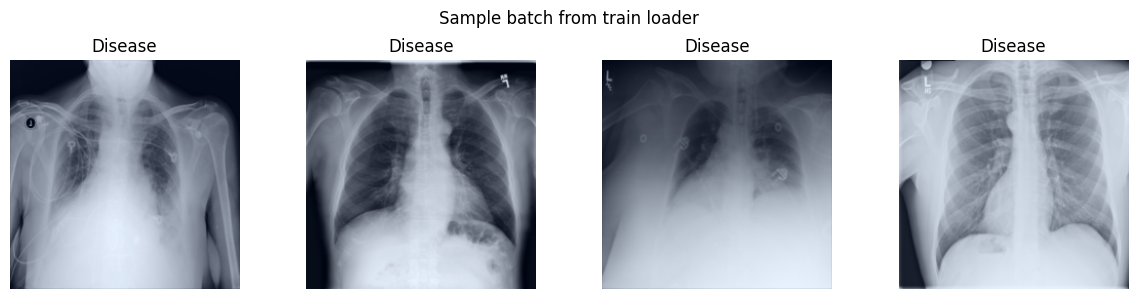

Image pipeline is working. Ready for modeling.


: 

In [ ]:
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")   # should be [32, 3, 224, 224]
print(f"Labels:      {labels[:8].tolist()}")

# Display the first 4 images from the batch
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()  # convert from tensor to displayable format
    img = (img - img.min()) / (img.max() - img.min())  # rescale for display only
    ax.imshow(img, cmap="gray")
    ax.set_title("Disease" if labels[i] == 1 else "No Finding")
    ax.axis("off")
plt.suptitle("Sample batch from train loader")
plt.tight_layout()
plt.show()

print("Image pipeline is working. Ready for modeling.")